# LLM Skills & Metacognition Training Pipeline
## GSM8K Math Problems — Results & Analysis

This notebook presents the results of the skills-based training pipeline
inspired by Arora et al. (Princeton).

**Pipeline Steps:**
1. Skill Extraction from GSM8K problems
2. Task Generation per skill
3. Chain of Thought Evaluation
4. Difficulty Sorting + Visualization

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path

In [2]:
# Load all data files
with open("data/skills.json") as f:
    skills = json.load(f)

with open("data/tasks.json") as f:
    tasks = json.load(f)

with open("data/evaluations.json") as f:
    evaluations = json.load(f)

print(f"✅ Skills loaded   : {len(skills)}")
print(f"✅ Tasks loaded    : {len(tasks)}")
print(f"✅ Evaluations loaded: {len(evaluations)}")

✅ Skills loaded   : 37
✅ Tasks loaded    : 111
✅ Evaluations loaded: 111


In [3]:
# Display extracted skills as table
df_skills = pd.DataFrame(skills)
df_skills.index += 1  # Start index at 1
print("📋 Extracted Skills:\n")
df_skills

📋 Extracted Skills:



,uid,skill_name
1,c4f1-b34e-335b-303c,calculate_total_sales_amount
2,7092-69ab-7855-9079,apply_fractional_operations
3,7205-498b-0dfc-7639,perform_addition_of_numbers
4,3fd8-b979-f729-6d3b,calculate_hourly_earnings
5,cceb-e520-3caa-e26d,convert_time_to_hours
6,1ab5-fd59-95ca-cf36,apply_multiplication_to_find_earnings
7,3f89-2118-9731-376d,calculate_total_amount_saved
8,a480-e0d3-4c3a-29cc,determine_remaining_amount_needed
9,4b2d-3a51-45c0-1a09,apply_basic_arithmetic_operations
10,a5d7-0b27-db4b-0eac,interpret_word_problem_context


In [4]:
df = pd.DataFrame(evaluations)

total = len(df)
passed = int(df["is_correct"].sum())
failed = total - passed
rate = (passed / total * 100) if total > 0 else 0

print("="*50)
print(f"📊 OVERALL RESULTS")
print("="*50)
print(f"✅ PASSED   : {passed}/{total}")
print(f"❌ FAILED   : {failed}/{total}")
print(f"📈 PASS RATE: {rate:.1f}%")
print("="*50)

# Per difficulty
print("\n📋 BY DIFFICULTY:")
for diff in ["easy", "medium", "hard"]:
    subset = df[df["difficulty"] == diff]
    if len(subset) == 0:
        continue
    p = int(subset["is_correct"].sum())
    t = len(subset)
    r = (p / t * 100)
    bar = "█" * int(r/10) + "░" * (10 - int(r/10))
    print(f"  {diff.upper():8} [{bar}] {r:.0f}% ({p}/{t})")

📊 OVERALL RESULTS
✅ PASSED   : 109/111
❌ FAILED   : 2/111
📈 PASS RATE: 98.2%

📋 BY DIFFICULTY:
  EASY     [██████████] 100% (37/37)
  MEDIUM   [██████████] 100% (37/37)
  HARD     [█████████░] 95% (35/37)


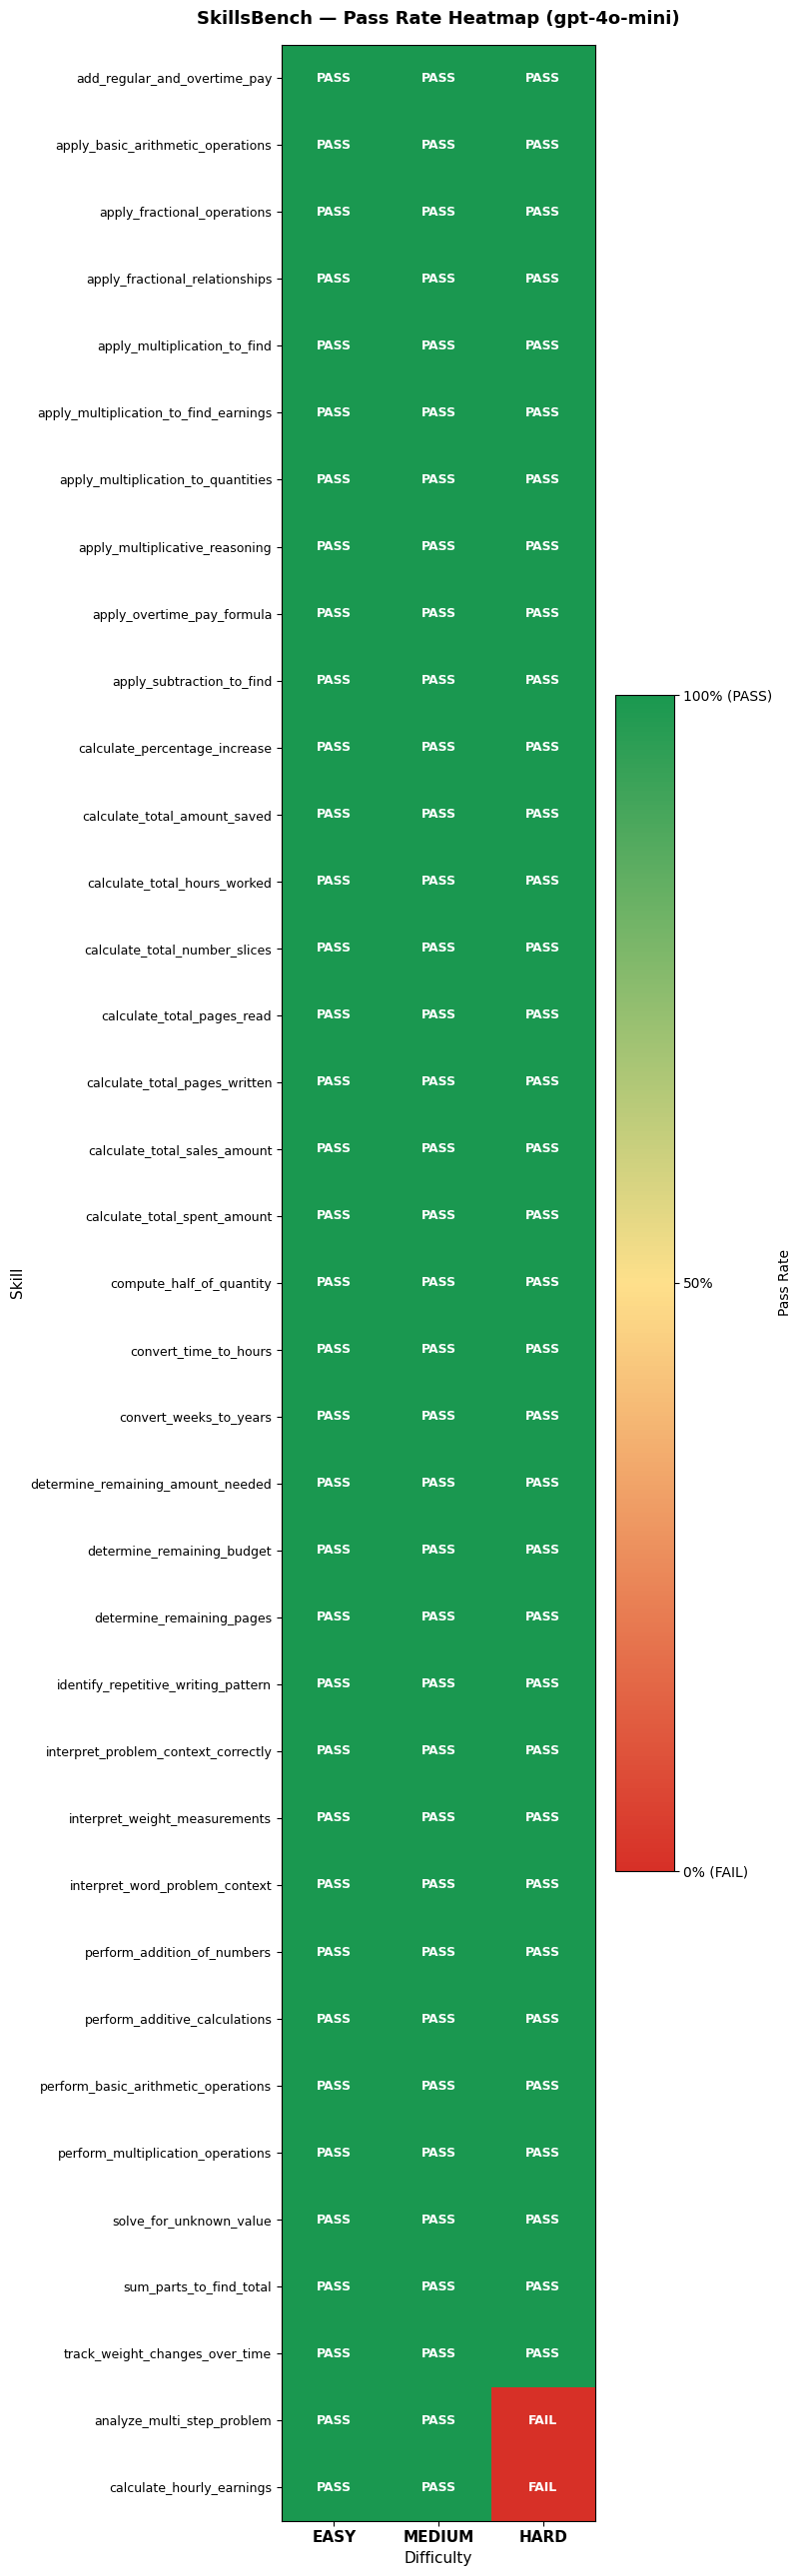

✅ Heatmap saved to outputs/heatmap.png


In [5]:
# Build matrix
difficulty_order = ["easy", "medium", "hard"]
matrix = df.pivot_table(
    index="skill_name",
    columns="difficulty",
    values="is_correct",
    aggfunc="mean"
 ).reindex(columns=difficulty_order)

matrix = matrix.sort_values(by=difficulty_order, ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(8, max(4, len(matrix) * 0.7)))

cmap = mcolors.LinearSegmentedColormap.from_list(
    "pass_fail", ["#d73027", "#fee08b", "#1a9850"]
 )

im = ax.imshow(matrix.values, cmap=cmap, vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(matrix.columns)))
ax.set_xticklabels([c.upper() for c in matrix.columns], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(matrix.index)))
ax.set_yticklabels(matrix.index, fontsize=9)

for i in range(len(matrix.index)):
    for j in range(len(matrix.columns)):
        val = matrix.values[i, j]
        label = "N/A" if np.isnan(val) else ("PASS" if val >= 0.5 else "FAIL")
        ax.text(j, i, label, ha="center", va="center",
               fontsize=9, color="white", fontweight="bold")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Pass Rate", fontsize=10)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["0% (FAIL)", "50%", "100% (PASS)"])

ax.set_title("SkillsBench — Pass Rate Heatmap (gpt-4o-mini)", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Difficulty", fontsize=11)
ax.set_ylabel("Skill", fontsize=11)

plt.tight_layout()
plt.savefig("outputs/heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap saved to outputs/heatmap.png")

In [6]:
# Show sample Chain of Thought para makita ng assessor
sample = evaluations[0]

print(f"📝 SAMPLE CHAIN OF THOUGHT")
print(f"{'='*50}")
print(f"Problem  : {sample['problem']}")
print(f"Skill    : {sample['skill_name']}")
print(f"Difficulty: {sample['difficulty'].upper()}")
print(f"{'='*50}\n")

print("🧠 Reasoning Steps:")
for step in sample["steps"]:
    print(f"\n  Step {step['step_number']}: {step['reasoning']}")
    print(f"  Skill used: {step['skill_used']}")

print(f"\n{'='*50}")
print(f"Final Answer : {sample['final_answer']}")
print(f"Correct Answer: {sample['correct_answer']}")
print(f"Result       : {'✅ PASS' if sample['is_correct'] else '❌ FAIL'}")

📝 SAMPLE CHAIN OF THOUGHT
Problem  : Lucy sells 3 lemonade cups for $2 each. How much money does she make in total?
Skill    : calculate_total_sales_amount
Difficulty: EASY

🧠 Reasoning Steps:

  Step 1: Multiply the number of cups sold by the price per cup to find the total earnings.
  Skill used: multiply_quantity_by_price

Final Answer : 6
Correct Answer: 6
Result       : ✅ PASS


## Model Used

- gpt-4o-mini

## Key Findings

- Overall pass rate is 98.2% (109/111)
- Easy and medium tasks are perfect at 100% each
- Hard tasks dip slightly to 94.6% (35/37)
- Lowest pass rates: calculate_hourly_earnings (2/3) and analyze_multi_step_problem (2/3)

## Next Steps (Training Loop)

1. Add more hard tasks for the two weakest skills
2. Generate 12-16 variations per failing pattern
3. Keep best 4 examples for fine-tuning
4. Re-evaluate to measure improvement

## Difficulty Sorting by Performance

This section orders tasks from easiest to hardest based on model performance.

In [7]:
# Sort tasks easy to hard by model performance
df_sorted = df.copy()
difficulty_rank = {"easy": 1, "medium": 2, "hard": 3}
df_sorted["difficulty_rank"] = df_sorted["difficulty"].map(difficulty_rank)
df_sorted["performance_rank"] = df_sorted["is_correct"].astype(int)

# Failing tasks first, then harder difficulties, then more steps
df_sorted = df_sorted.sort_values(
    by=["performance_rank", "difficulty_rank", "num_steps"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("📌 Hardest tasks for this model (top 20)")
display(df_sorted[["task_uid", "skill_name", "difficulty", "is_correct", "num_steps", "problem"]].head(20))

📌 Hardest tasks for this model (top 20)


,task_uid,skill_name,difficulty,is_correct,num_steps,problem
0,6bea-0c42-88bc-0505,calculate_hourly_earnings,hard,False,4,Emma is a babysitter who earns $15 per hour. I...
1,07ae-85e1-88f1-443c,analyze_multi_step_problem,hard,False,4,Sophia has 10 marbles. She gives 3 marbles to ...
2,7dd0-3541-067a-dbb2,apply_overtime_pay_formula,hard,True,5,"Sophia worked a total of 50 hours this week, w..."
3,1d2e-f89f-7258-2da7,calculate_total_sales_amount,hard,True,4,A bakery sells 12 muffins for $3 each and 10 c...
4,a8aa-24e2-84ed-6fbb,apply_fractional_operations,hard,True,4,A recipe requires 3/4 cup of sugar. If you wan...
5,82cd-46a2-6945-a8d1,calculate_total_pages_read,hard,True,4,"Emily has three books. In the first book, she ..."
6,d428-4421-5a3a-21fe,track_weight_changes_over_time,hard,True,4,Samantha tracked her weight over three months....
7,de1b-41c6-849b-2200,interpret_weight_measurements,hard,True,4,"A watermelon weighs 10 pounds, a cantaloupe we..."
8,40fa-c830-4926-0dac,apply_multiplication_to_find_earnings,hard,True,3,Aisha makes handmade bracelets and sells them ...
9,4f8d-4889-f4c8-1fcb,calculate_total_amount_saved,hard,True,3,"Emma saves $15 every week, and she has been sa..."


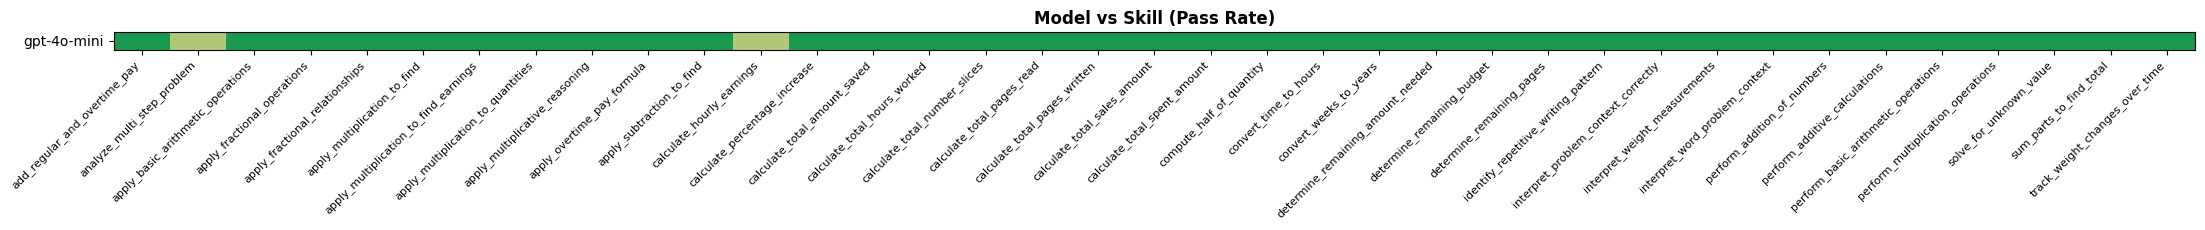

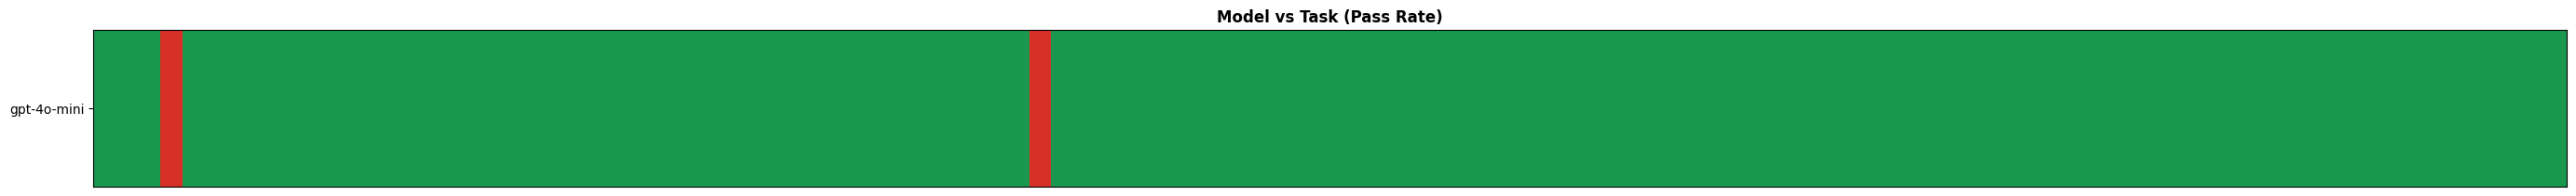

✅ Saved: outputs/model_vs_skill.png
✅ Saved: outputs/model_vs_task.png


In [8]:
# Model vs Skill / Task matrices (single-model setup)
model_name = "gpt-4o-mini"
df_model = df.copy()
df_model["model"] = model_name

# Model vs Skill heatmap (1 x N)
model_skill = df_model.pivot_table(
    index="model",
    columns="skill_name",
    values="is_correct",
    aggfunc="mean"
 )

fig, ax = plt.subplots(figsize=(max(6, len(model_skill.columns) * 0.6), 2.4))
im = ax.imshow(model_skill.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks([0])
ax.set_yticklabels(model_skill.index)
ax.set_xticks(range(len(model_skill.columns)))
ax.set_xticklabels(model_skill.columns, rotation=45, ha="right", fontsize=8)
ax.set_title("Model vs Skill (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/model_vs_skill.png", dpi=150, bbox_inches="tight")
plt.show()

# Model vs Task heatmap (1 x N)
model_task = df_model.pivot_table(
    index="model",
    columns="task_uid",
    values="is_correct",
    aggfunc="mean"
 )

fig, ax = plt.subplots(figsize=(max(6, len(model_task.columns) * 0.25), 2.2))
im = ax.imshow(model_task.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks([0])
ax.set_yticklabels(model_task.index)
ax.set_xticks([])
ax.set_title("Model vs Task (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/model_vs_task.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved: outputs/model_vs_skill.png")
print("✅ Saved: outputs/model_vs_task.png")

## Skill vs Task Matrices

Single-model view of skill-to-task performance (and its transpose).
High-density charts, so use them to spot rows/columns with repeated FAIL blocks.
If you need a summary, focus on the worst 3 skills and the top failing tasks.

In [9]:
# Quick summary: worst skills and failing tasks
skill_summary = df.groupby("skill_name").agg(
    total=("is_correct", "count"),
    passed=("is_correct", "sum")
).reset_index()
skill_summary["pass_rate"] = (skill_summary["passed"] / skill_summary["total"]).fillna(0)
skill_summary = skill_summary.sort_values(by="pass_rate", ascending=True)

task_summary = df.groupby("task_uid").agg(
    skill_name=("skill_name", "first"),
    difficulty=("difficulty", "first"),
    total=("is_correct", "count"),
    passed=("is_correct", "sum"),
    problem=("problem", "first")
).reset_index()
task_summary["pass_rate"] = (task_summary["passed"] / task_summary["total"]).fillna(0)
task_summary = task_summary.sort_values(by=["pass_rate", "difficulty"], ascending=[True, False])

print("📉 Worst 3 skills by pass rate")
display(skill_summary[["skill_name", "pass_rate", "passed", "total"]].head(3))
print("\n❌ Top 5 failing tasks")
display(task_summary[["task_uid", "skill_name", "difficulty", "pass_rate", "problem"]].head(5))

📉 Worst 3 skills by pass rate


,skill_name,pass_rate,passed,total
1,analyze_multi_step_problem,0.666667,2,3
11,calculate_hourly_earnings,0.666667,2,3
2,apply_basic_arithmetic_operations,1.000000,3,3



❌ Top 5 failing tasks


,task_uid,skill_name,difficulty,pass_rate,problem
3,07ae-85e1-88f1-443c,analyze_multi_step_problem,hard,0.0,Sophia has 10 marbles. She gives 3 marbles to ...
42,6bea-0c42-88bc-0505,calculate_hourly_earnings,hard,0.0,Emma is a babysitter who earns $15 per hour. I...
6,126b-e1d0-d7c7-2440,perform_additive_calculations,medium,1.0,Tom has 12 marbles. He finds 7 more marbles in...
8,1770-dd2a-5be6-3d18,apply_multiplication_to_quantities,medium,1.0,A pack of pencils contains 6 pencils. If you b...
15,25b9-70c4-8199-ff06,perform_multiplication_operations,medium,1.0,A pack of stickers has 6 stickers. If you buy ...


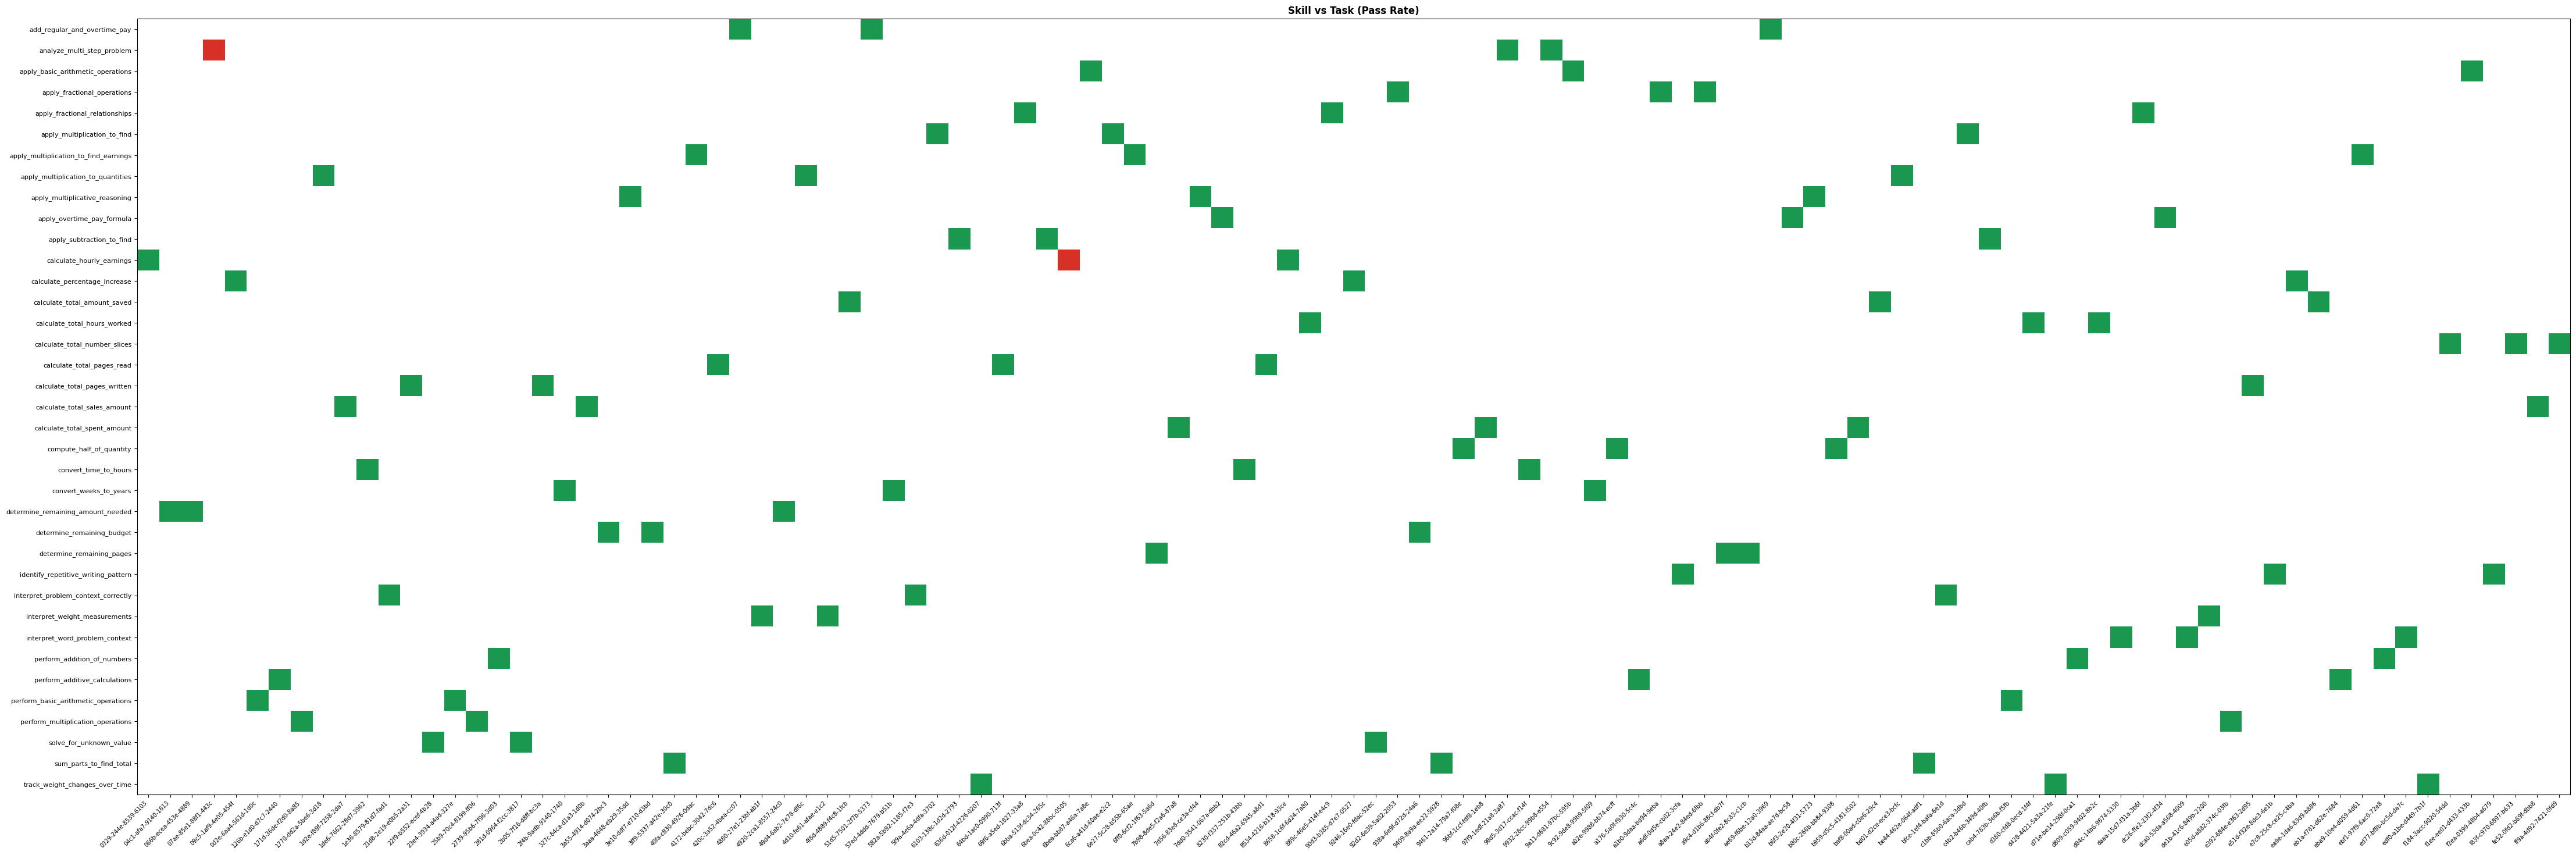

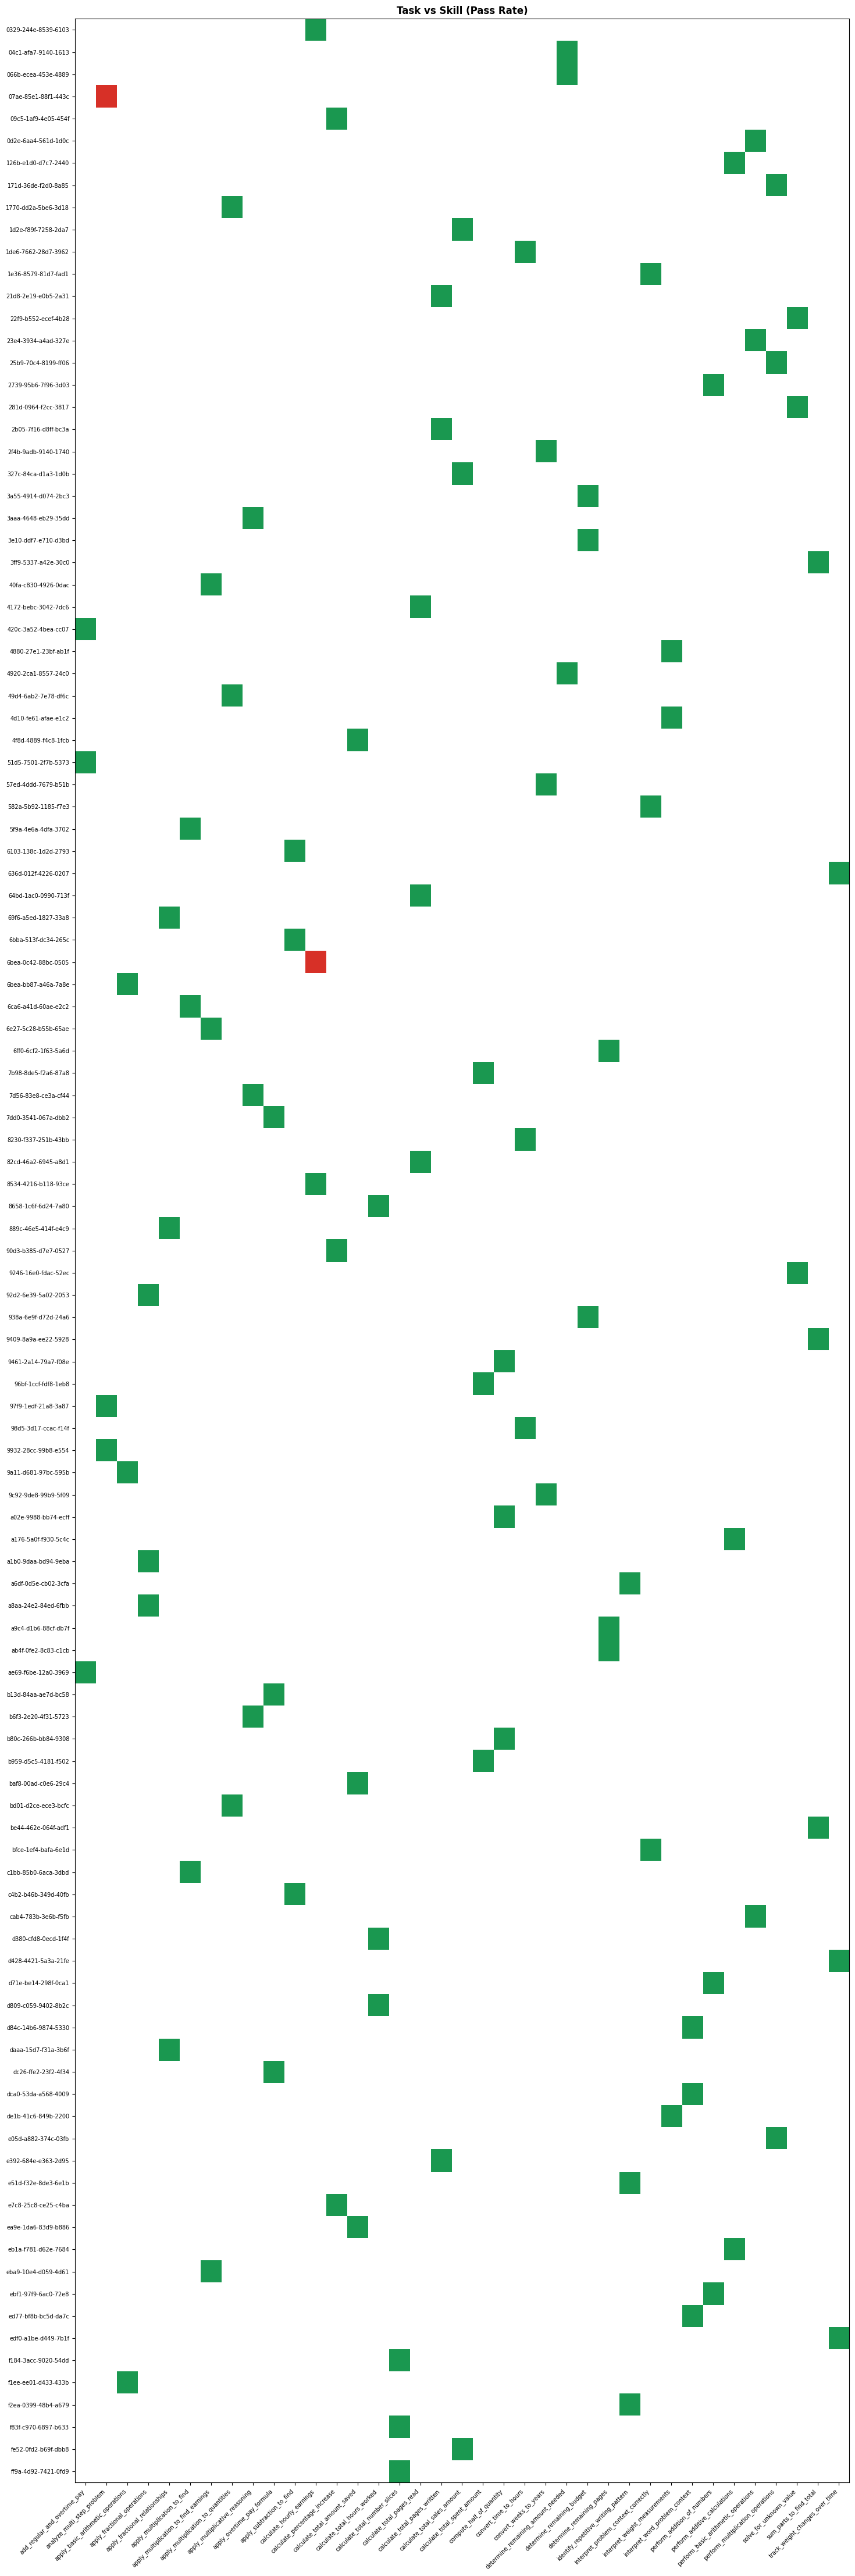

✅ Saved: outputs/skill_vs_task.png
✅ Saved: outputs/task_vs_skill.png


In [12]:
# Skill vs Task heatmap
skill_task = df.pivot_table(
    index="skill_name",
    columns="task_uid",
    values="is_correct",
    aggfunc="mean"
 )

fig, ax = plt.subplots(figsize=(max(10, len(skill_task.columns) * 0.4), max(5, len(skill_task.index) * 0.4)))
im = ax.imshow(skill_task.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks(range(len(skill_task.index)))
ax.set_yticklabels(skill_task.index, fontsize=8)
ax.set_xticks(range(len(skill_task.columns)))
ax.set_xticklabels(skill_task.columns, rotation=45, ha="right", fontsize=7)
ax.set_title("Skill vs Task (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/skill_vs_task.png", dpi=150, bbox_inches="tight")
plt.show()

# Task vs Skill heatmap (transpose)
task_skill = skill_task.T
fig, ax = plt.subplots(figsize=(max(10, len(task_skill.columns) * 0.4), max(5, len(task_skill.index) * 0.4)))
im = ax.imshow(task_skill.values, vmin=0, vmax=1, cmap=cmap, aspect="auto")
ax.set_yticks(range(len(task_skill.index)))
ax.set_yticklabels(task_skill.index, fontsize=7)
ax.set_xticks(range(len(task_skill.columns)))
ax.set_xticklabels(task_skill.columns, rotation=45, ha="right", fontsize=7)
ax.set_title("Task vs Skill (Pass Rate)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/task_vs_skill.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Saved: outputs/skill_vs_task.png")
print("✅ Saved: outputs/task_vs_skill.png")